In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


In [4]:
df = pd.read_csv("merged_data.csv")
df['Diabetes_Status'] = df['Diabetes_Status'].map({1:1, 2:0})
df = df.drop(columns=['SEQN'])
# df.hist(figsize=(20,20))
# from tabulate import tabulate

# nulls = df.isnull().sum().reset_index()
# nulls.columns = ['Column', 'Missing Values']
# print(tabulate(nulls, headers='keys', tablefmt='psql'))
# print(df.shape)

#CLEANING
df_clean = df.dropna()
df_clean = df_clean[(df_clean["Diabetes_Status"] != 3) & (df_clean["Diabetes_Status"] != 9)]
df_clean.shape
# df_clean.hist(figsize=(20,20))
# print(df_clean.isnull().sum())

(3167, 13)

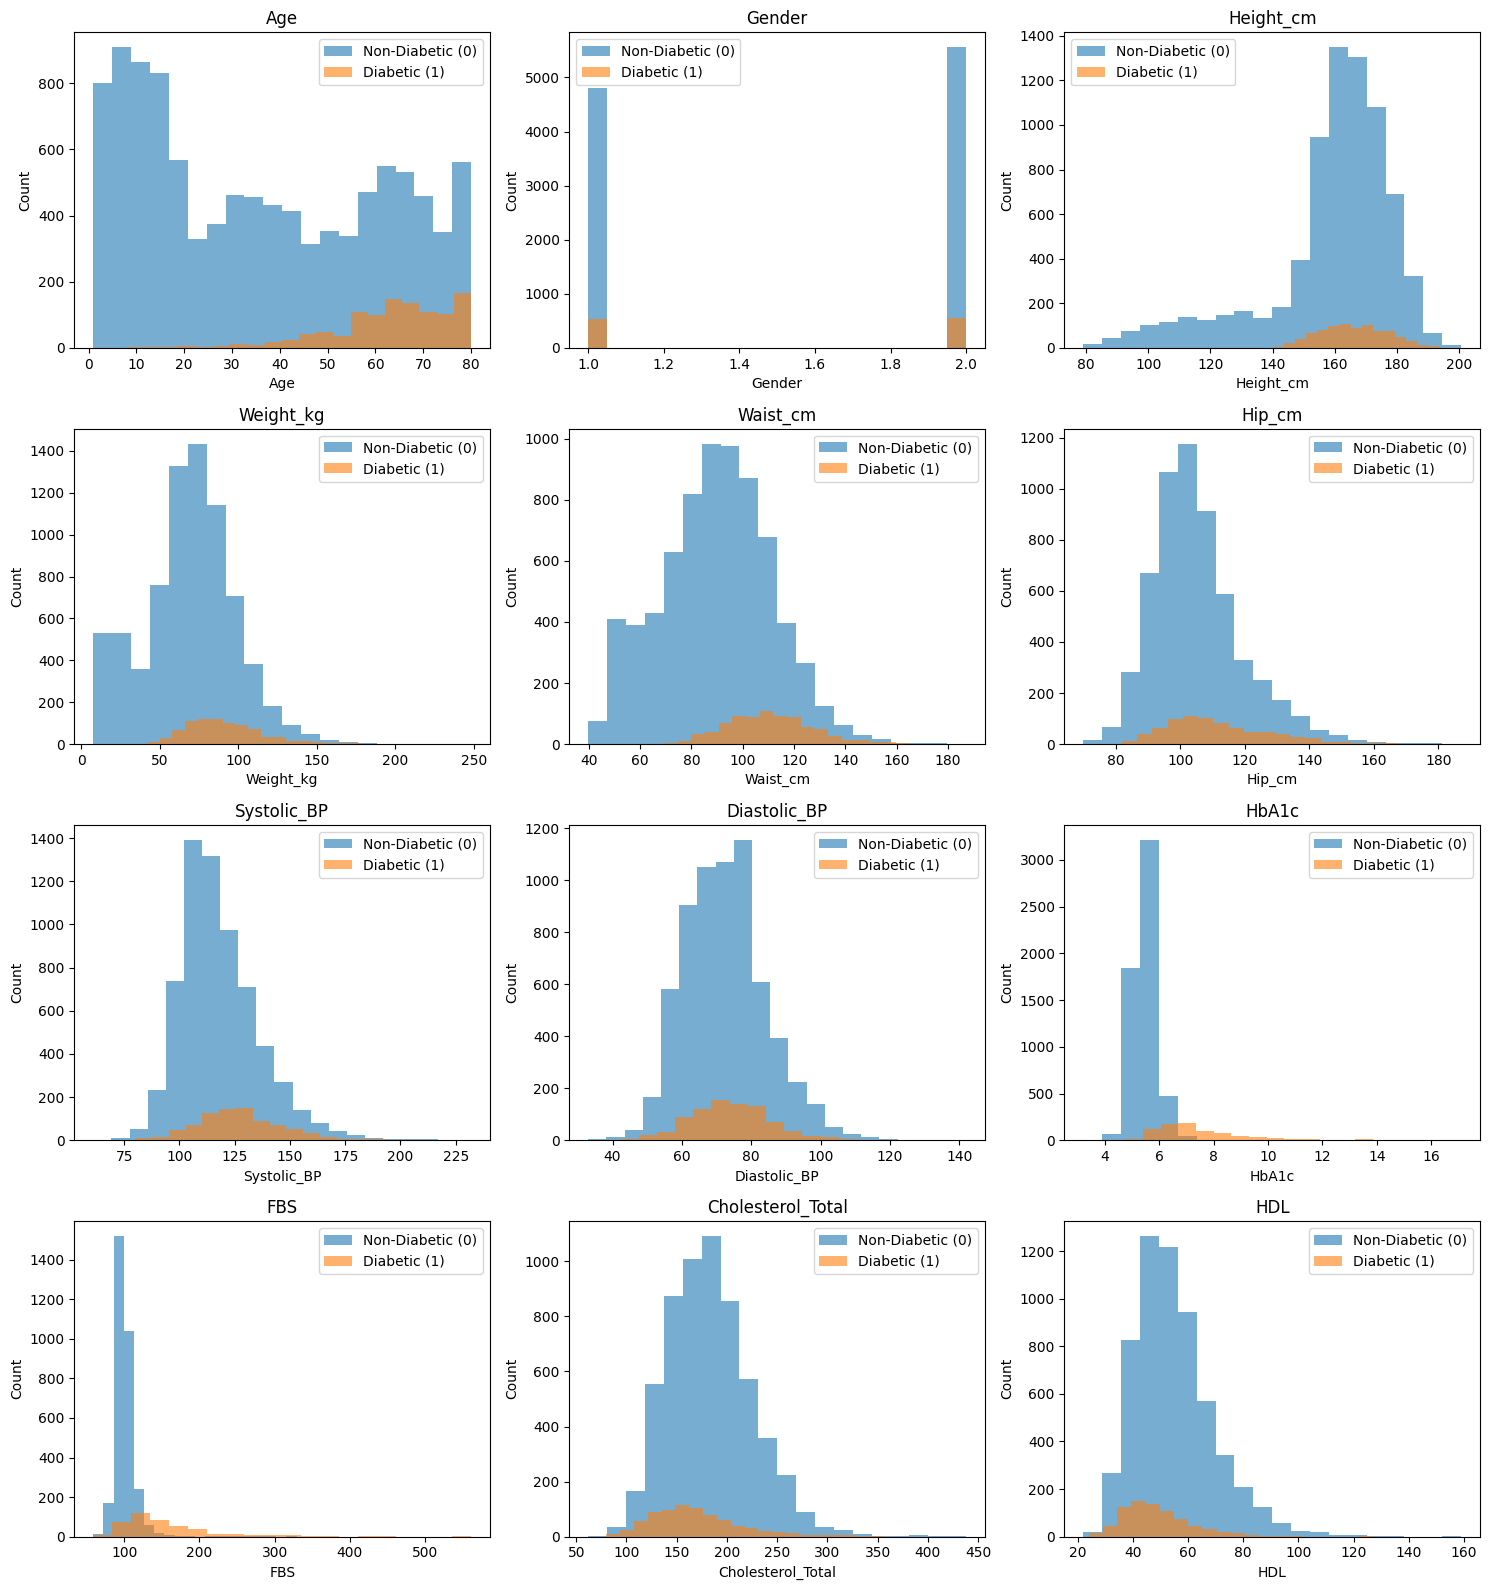

In [ ]:
import matplotlib.pyplot as plt

target = "Diabetes_Status"
features = df_clean.drop(columns=[target]).columns

# create grid: adjust rows/cols depending on number of features
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols  # auto rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()  # make axes iterable

for i, col in enumerate(features):
    ax = axes[i]
    df[df[target] == 0][col].plot(kind="hist", bins=20, alpha=0.6, label="Non-Diabetic (0)", ax=ax)
    df[df[target] == 1][col].plot(kind="hist", bins=20, alpha=0.6, label="Diabetic (1)", ax=ax)

    ax.set_title(f"{col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend()

# remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("diabetes_distributions.png", dpi=300)  # save image
plt.show()


<Axes: >

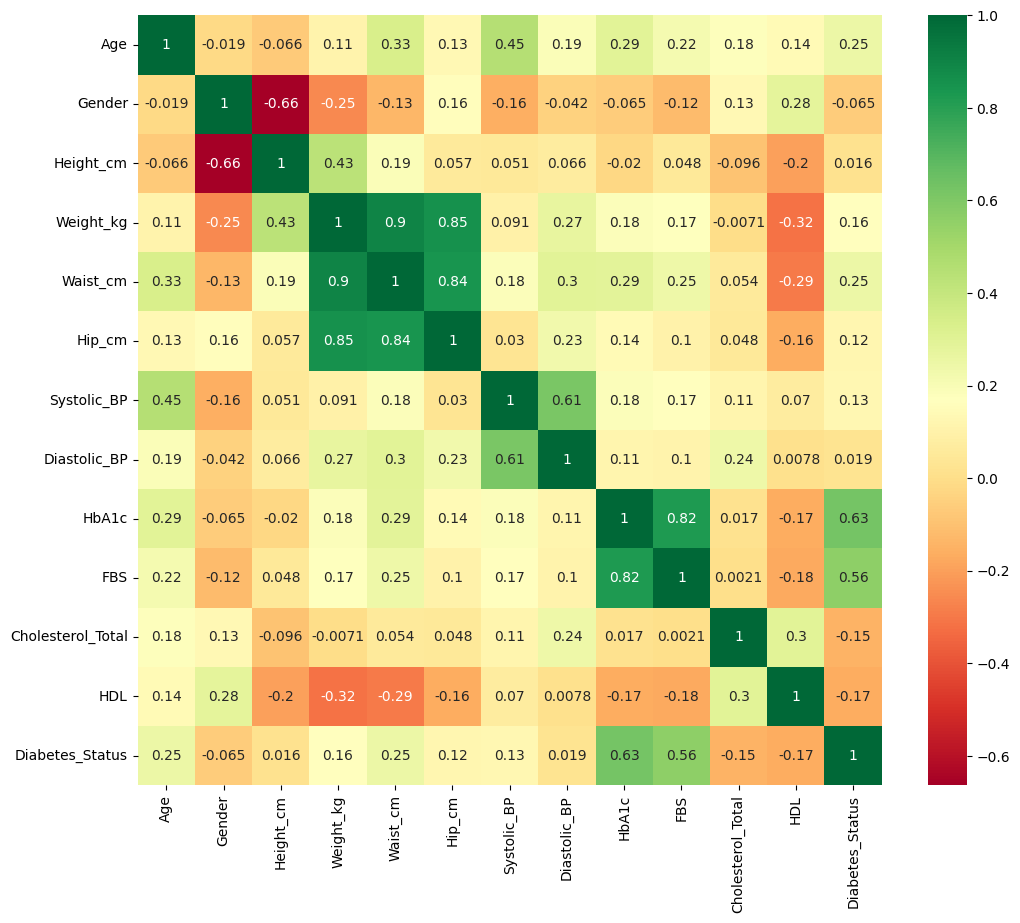

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean.corr(), annot=True, cmap='RdYlGn')

In [5]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["Diabetes_Status"])
y = df_clean["Diabetes_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train ratio:\n", X_train.value_counts(normalize=True))
print("Valid ratio:\n", X_test.value_counts(normalize=True))


Train ratio:
 Age   Gender  Height_cm  Weight_kg  Waist_cm  Hip_cm  Systolic_BP  Diastolic_BP  HbA1c  FBS    Cholesterol_Total  HDL 
80.0  2.0     171.7      75.1       89.5      110.2   155.0        55.0          5.7    92.0   201.0              63.0    0.000395
12.0  1.0     136.7      39.0       69.5      77.6    96.0         70.0          5.2    105.0  126.0              43.0    0.000395
              148.6      46.7       72.2      72.2    113.0        68.0          5.0    100.0  174.0              35.0    0.000395
              148.8      53.1       86.4      89.1    111.0        73.0          5.0    104.0  216.0              50.0    0.000395
              152.7      62.4       90.5      97.5    94.0         62.0          5.2    96.0   184.0              51.0    0.000395
                                                                                                                            ...   
              161.2      54.7       76.5      87.9    106.0        47.0          

In [ ]:
train = pd.DataFrame(X_train, columns=X.columns)
train["Diabetes_Status"] = y_train

valid = pd.DataFrame(X_valid, columns=X.columns)
valid["Diabetes_Status"] = y_valid

test = pd.DataFrame(X_test, columns=X.columns)
test["Diabetes_Status"] = y_test

In [ ]:
train['Diabetes_Status'].value_counts()
valid['Diabetes_Status'].value_counts()
test['Diabetes_Status'].value_counts()


,count
Diabetes_Status,
0.0,557
1.0,77


# **Raw Dataset Training**
all values are raw that contains NaN.

GENDER:
*   MALE: 1,
*   FEMALE: 2

DIABETES STATS:
*   YES: 1
*   NO: 0





# Feature Importance

Gini Importance

In [6]:
import shap
feature_names = df_clean.columns[:-1]
importances = forest_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False)
print(feature_imp_df)

plt.figure(figsize=(8, 4))
plt.barh(feature_names, importances, color='skyblue')
plt.xlabel('Gini Importance')
plt.title('Feature Importance - Gini Importance')
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()

NameError: name 'forest_model' is not defined

# TRAINING

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, roc_auc_score, precision_score, accuracy_score, f1_score

In [82]:
numeric_features = X_train.columns.tolist()

over = SMOTE()
under = RandomUnderSampler()

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)],
    remainder='passthrough'  # keep any non-numeric features if present
)

preprocessor_SMOTE = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)],
    remainder='passthrough'  # keep any non-numeric features if present
)
print(numeric_features)

['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Waist_cm', 'Hip_cm', 'Systolic_BP', 'Diastolic_BP']


In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [30]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
}

xgb = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC:", grid_search.best_score_)


Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best ROC-AUC: 0.9559108177328848



🔹 Training Logistic Regression...
ROC-AUC: 0.9780
F1-Score: 0.7157
              precision    recall  f1-score   support

         0.0       0.99      0.90      0.95       558
         1.0       0.57      0.96      0.72        76

    accuracy                           0.91       634
   macro avg       0.78      0.93      0.83       634
weighted avg       0.94      0.91      0.92       634



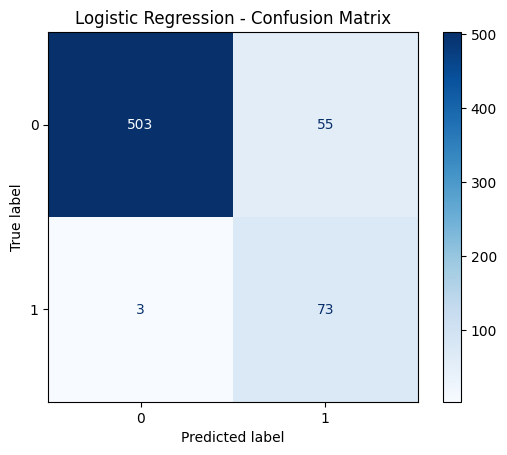


🔹 Training Random Forest...
ROC-AUC: 0.9672
F1-Score: 0.7314
              precision    recall  f1-score   support

         0.0       0.98      0.94      0.96       558
         1.0       0.65      0.84      0.73        76

    accuracy                           0.93       634
   macro avg       0.81      0.89      0.84       634
weighted avg       0.94      0.93      0.93       634



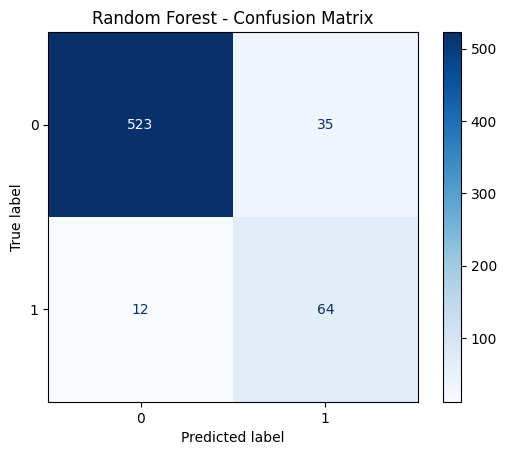


🔹 Training KNN...
ROC-AUC: 0.9239
F1-Score: 0.6701
              precision    recall  f1-score   support

         0.0       0.98      0.90      0.94       558
         1.0       0.55      0.87      0.67        76

    accuracy                           0.90       634
   macro avg       0.76      0.88      0.80       634
weighted avg       0.93      0.90      0.91       634



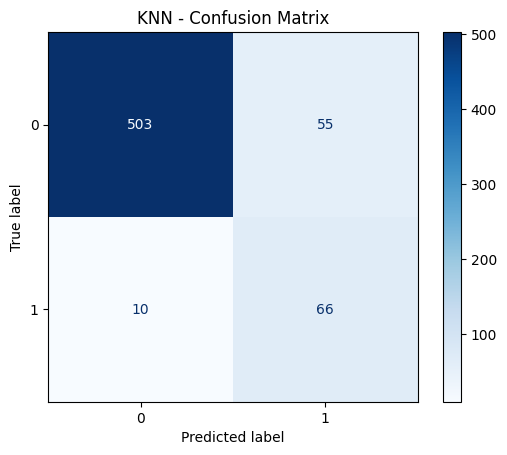


🔹 Training Naive Bayes...
ROC-AUC: 0.9646
F1-Score: 0.7174
              precision    recall  f1-score   support

         0.0       0.98      0.92      0.95       558
         1.0       0.61      0.87      0.72        76

    accuracy                           0.92       634
   macro avg       0.80      0.90      0.83       634
weighted avg       0.94      0.92      0.92       634



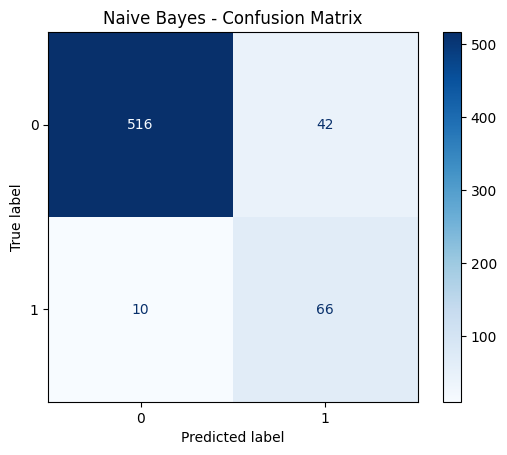


🔹 Training SVM...
ROC-AUC: 0.9687
F1-Score: 0.6947
              precision    recall  f1-score   support

         0.0       0.98      0.91      0.95       558
         1.0       0.58      0.87      0.69        76

    accuracy                           0.91       634
   macro avg       0.78      0.89      0.82       634
weighted avg       0.93      0.91      0.92       634



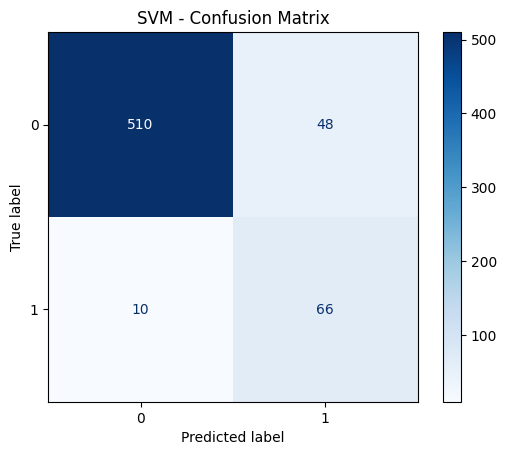


🔹 Training XGBoost...
ROC-AUC: 0.9634
F1-Score: 0.7439
              precision    recall  f1-score   support

         0.0       0.97      0.95      0.96       558
         1.0       0.69      0.80      0.74        76

    accuracy                           0.93       634
   macro avg       0.83      0.88      0.85       634
weighted avg       0.94      0.93      0.94       634



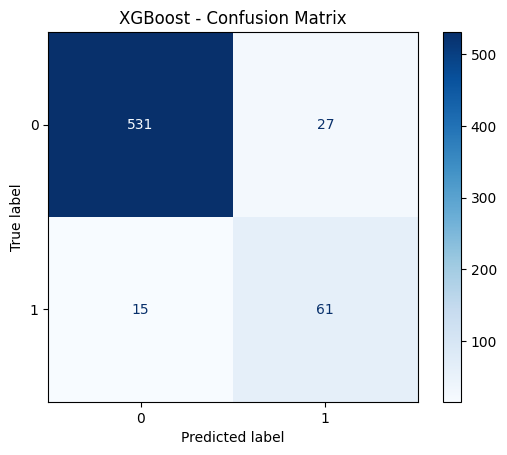


🏆 BEST MODEL: Logistic Regression with ROC-AUC: 0.9780


In [64]:
def train_and_evaluate_model_SMOTE(models, X_train, y_train, X_valid, y_valid):
    """
    Enhanced version that returns model performance for comparison
    """
    results = {}

    for name, model in models.items():
        print(f"\n🔹 Training {name}...")

        if name == "Random Forest" or name == "XGBoost":
          pipe = ImbPipeline([
              ('over', over),
              ('under', under),
              ('model', model)
          ])
        else:
          pipe = ImbPipeline([
              ('preprocess', preprocessor),
              ('over', over),
              ('under', under),
              ('model', model)
          ])

        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_valid)
        y_proba = pipe.predict_proba(X_valid)[:, 1]

        # Calculate multiple metrics
        roc_auc = roc_auc_score(y_valid, y_proba)
        accuracy = accuracy_score(y_valid, y_pred)
        precision = precision_score(y_valid, y_pred, zero_division=0)
        recall = recall_score(y_valid, y_pred, zero_division=0)
        f1 = f1_score(y_valid, y_pred, zero_division=0)

        # Store results
        results[name] = {
            'model': pipe,
            'roc_auc': roc_auc,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'predictions': y_pred,
            'probabilities': y_proba
        }

        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(classification_report(y_valid, y_pred, digits=2))

        cm = confusion_matrix(y_valid, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title(f"{name} - Confusion Matrix")
        plt.show()

    return results

# Usage
results = train_and_evaluate_model_SMOTE(models, X_train, y_train, X_test, y_test)

# Find best model
best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['model']
print(f"\n🏆 BEST MODEL: {best_model_name} with ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")


🔹 Training Logistic Regression 2...
ROC-AUC: 0.9784
F1-Score: 0.7273
              precision    recall  f1-score   support

         0.0       0.99      0.91      0.95       558
         1.0       0.59      0.95      0.73        76

    accuracy                           0.91       634
   macro avg       0.79      0.93      0.84       634
weighted avg       0.94      0.91      0.92       634



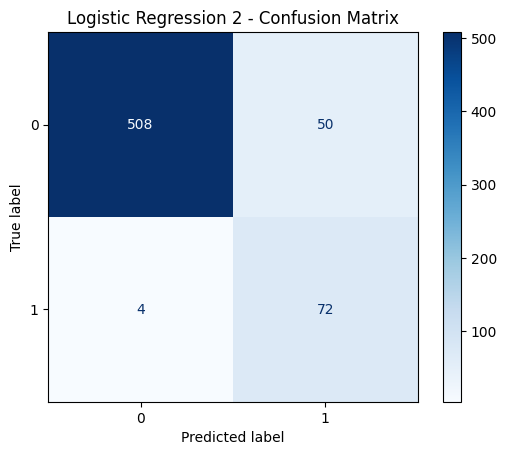

{'Logistic Regression 2': {'model': Pipeline(steps=[('preprocess',
                   ColumnTransformer(remainder='passthrough',
                                     transformers=[('num', StandardScaler(),
                                                    ['Age', 'Gender', 'Height_cm',
                                                     'Weight_kg', 'Waist_cm',
                                                     'Hip_cm', 'Systolic_BP',
                                                     'Diastolic_BP', 'HbA1c',
                                                     'FBS', 'Cholesterol_Total',
                                                     'HDL'])])),
                  ('over', SMOTE()), ('under', RandomUnderSampler()),
                  ('model',
                   LogisticRegression(C=0.1, class_weight='balanced',
                                      max_iter=1000, random_state=42))]),
  'roc_auc': np.float64(0.9784003018298434),
  'accuracy': 0.9148264984227129,
  'precisi

In [13]:
models_lg = {
    "Logistic Regression 2": LogisticRegression(max_iter=1000,
                                                random_state=42,
                                                penalty='l2',
                                                C=0.1,
                                                class_weight='balanced'),
}

train_and_evaluate_model_SMOTE(models_lg, X_train, y_train, X_test, y_test)



🔹 Training XGBoost...
ROC-AUC: 0.9592
F1-Score: 0.7547
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.96       558
         1.0       0.72      0.79      0.75        76

    accuracy                           0.94       634
   macro avg       0.85      0.87      0.86       634
weighted avg       0.94      0.94      0.94       634



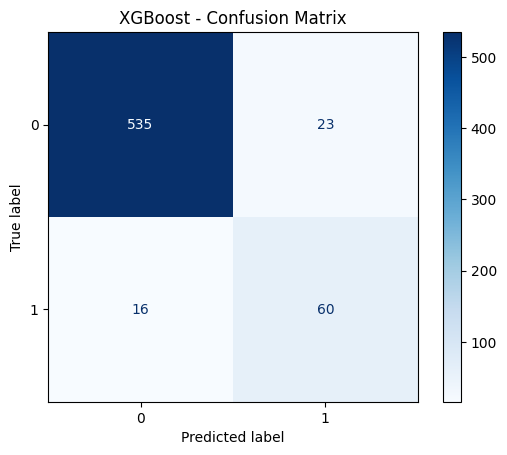

{'XGBoost': {'model': Pipeline(steps=[('over', SMOTE()), ('under', RandomUnderSampler()),
                  ('model',
                   XGBClassifier(base_score=None, booster=None, callbacks=None,
                                 colsample_bylevel=None, colsample_bynode=None,
                                 colsample_bytree=None, device=None,
                                 early_stopping_rounds=None,
                                 enable_categorical=False, eval_metric='logloss',
                                 feature_types=None, feature_weights=None,
                                 gamma=None, grow_policy=None,
                                 importance_type=None,
                                 interaction_constraints=None, learning_rate=None,
                                 max_bin=None, max_cat_threshold=None,
                                 max_cat_to_onehot=None, max_delta_step=None,
                                 max_depth=None, max_leaves=None,
                   

In [63]:
models_xg = {
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_estimators=100)
}

train_and_evaluate_model_SMOTE(models_xg, X_train, y_train, X_test, y_test)


In [ ]:


param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Best ROC-AUC: 0.9450001170058757


In [72]:
best_pipe = ImbPipeline([
    ('preprocess', preprocessor),
    ('over', over),
    ('under', under),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        penalty='l2',
        C=0.1,
        class_weight='balanced'
    ))
])

best_pipe.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Age', 'Gender', 'Height_cm',
                                                   'Weight_kg', 'Waist_cm',
                                                   'Hip_cm', 'Systolic_BP',
                                                   'Diastolic_BP', 'HbA1c',
                                                   'FBS', 'Cholesterol_Total',
                                                   'HDL'])])),
                ('over', SMOTE()), ('under', RandomUnderSampler()),
                ('model',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000, random_state=42))])

In [66]:
best_pipe = ImbPipeline([
    ('preprocess', preprocessor),
    ('over', over),
    ('under', under),
    ('model', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_estimators=100
    ))
])

best_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Age', 'Gender', 'Height_cm',
                                                   'Weight_kg', 'Waist_cm',
                                                   'Hip_cm', 'Systolic_BP',
                                                   'Diastolic_BP', 'HbA1c',
                                                   'FBS', 'Cholesterol_Total',
                                                   'HDL'])])),
                ('over', SMOTE()), ('under', RandomUnderSampler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callba...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [74]:
new_patient = pd.DataFrame([{
    'Age': 85,
    'Gender': 1,
    'Height_cm': 179.5,
    'Weight_kg': 86.9,
    'Waist_cm': 98.3,
    'Hip_cm': 102.9,
    'Systolic_BP': 135,
    'Diastolic_BP': 98,
    'HbA1c': 5,
    'FBS': 113,
    'Cholesterol_Total': 264,
    'HDL': 45
}])

prob = best_pipe.predict_proba(new_patient)[0]
print(f"Predicted Probability of No Diabetes: {prob[0]*100:.2f}%")
print(f"Predicted Probability of Diabetes: {prob[1]*100:.2f}%")




Predicted Probability of No Diabetes: 91.78%
Predicted Probability of Diabetes: 8.22%


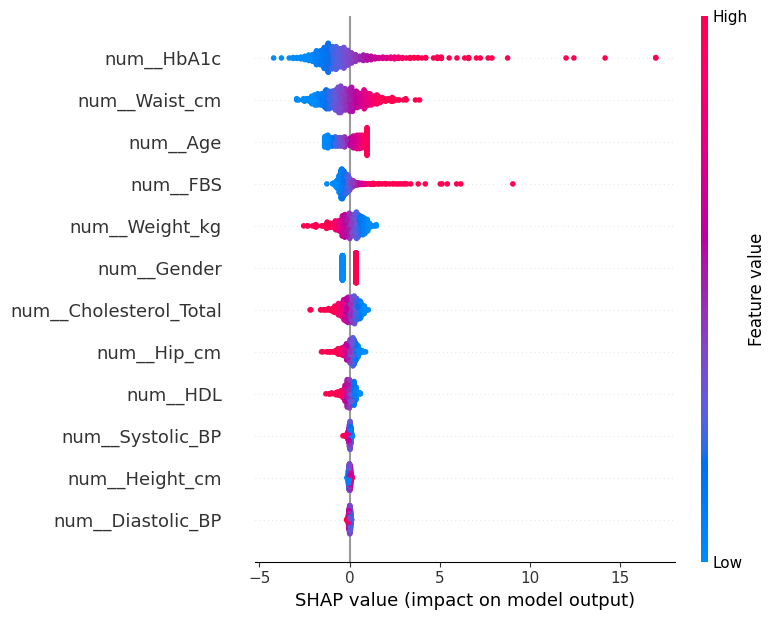

In [26]:
import shap
import matplotlib.pyplot as plt

# Get preprocessed data (apply same transformations used during training)
X_test_preprocessed = best_model.named_steps['preprocess'].transform(X_test)

# Get the logistic regression model itself
log_reg = best_model.named_steps['model']

# Initialize SHAP explainer for linear models
explainer = shap.Explainer(log_reg, X_test_preprocessed)

# Compute SHAP values
shap_values = explainer(X_test_preprocessed)

# Get feature names after preprocessing
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()

# Plot overall feature importance (global)
shap.summary_plot(shap_values, features=X_test_preprocessed, feature_names=feature_names)



🔹 Training Random Forest...
0.9676603987527166
              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97       557
         1.0       0.77      0.80      0.79        76

    accuracy                           0.95       633
   macro avg       0.87      0.89      0.88       633
weighted avg       0.95      0.95      0.95       633



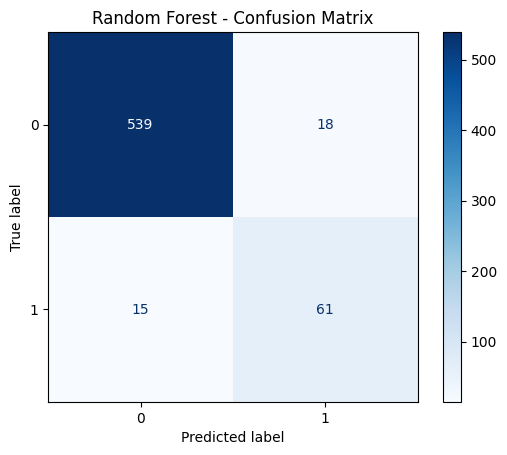

In [ ]:
models_RF = {
    "Random Forest": RandomForestClassifier(n_estimators=500, random_state=42)
  }

train_and_evaluate_model(models_RF, X_train, y_train, X_valid, y_valid)

In [ ]:
pipe = ImbPipeline([
    ('oversample', RandomOverSampler()),
    ('model', RandomForestClassifier(random_state=42))
])

# Define parameter grid
param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 5, 10, 20]
}

# Grid search (oversampling occurs correctly inside each fold)
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2
)

# ✅ Fit on the *original* imbalanced data
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'model__max_depth': 20, 'model__n_estimators': 300}
Best ROC-AUC: 0.9501132155507097


# WITHOUT GLUCOSE LEVELS MODEL

In case the user does not know any other features.

In [78]:
df_clean.columns
df_nogc = df_clean.drop(['HbA1c', 'FBS', 'Cholesterol_Total', 'HDL'], axis=1)
df_nogc.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Waist_cm', 'Hip_cm',
       'Systolic_BP', 'Diastolic_BP', 'Diabetes_Status'],
      dtype='object')

In [80]:
from sklearn.model_selection import train_test_split

X = df_nogc.drop(columns=["Diabetes_Status"])
y = df_nogc["Diabetes_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)




🔹 Training Logistic Regression...
ROC-AUC: 0.7942
F1-Score: 0.3822
              precision    recall  f1-score   support

         0.0       0.96      0.68      0.80       558
         1.0       0.25      0.79      0.38        76

    accuracy                           0.69       634
   macro avg       0.61      0.74      0.59       634
weighted avg       0.87      0.69      0.75       634



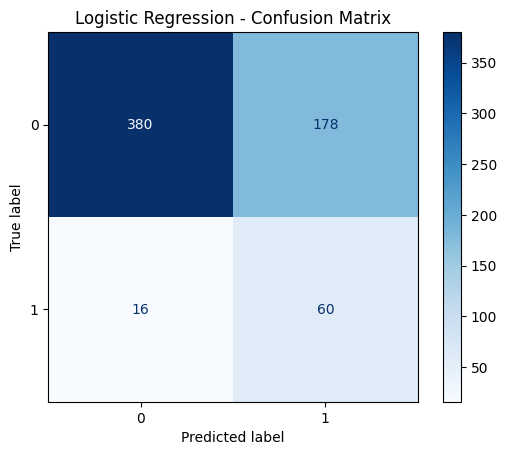


🔹 Training Random Forest...
ROC-AUC: 0.7666
F1-Score: 0.3103
              precision    recall  f1-score   support

         0.0       0.91      0.87      0.89       558
         1.0       0.28      0.36      0.31        76

    accuracy                           0.81       634
   macro avg       0.59      0.61      0.60       634
weighted avg       0.83      0.81      0.82       634



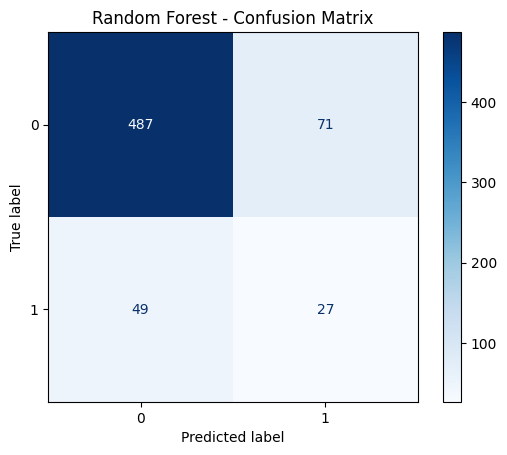


🔹 Training KNN...
ROC-AUC: 0.7372
F1-Score: 0.3525
              precision    recall  f1-score   support

         0.0       0.94      0.73      0.82       558
         1.0       0.24      0.64      0.35        76

    accuracy                           0.72       634
   macro avg       0.59      0.69      0.59       634
weighted avg       0.85      0.72      0.76       634



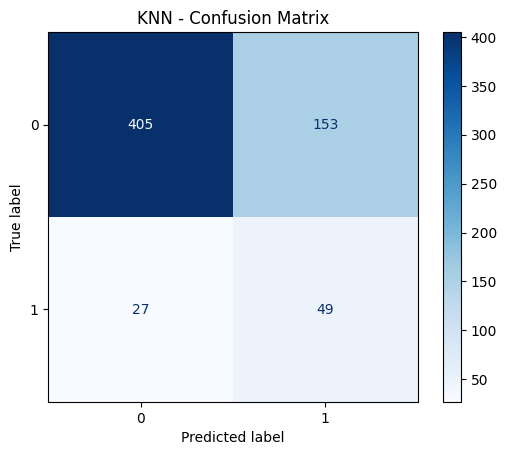


🔹 Training Naive Bayes...
ROC-AUC: 0.7704
F1-Score: 0.3508
              precision    recall  f1-score   support

         0.0       0.95      0.66      0.78       558
         1.0       0.23      0.75      0.35        76

    accuracy                           0.67       634
   macro avg       0.59      0.70      0.56       634
weighted avg       0.86      0.67      0.73       634



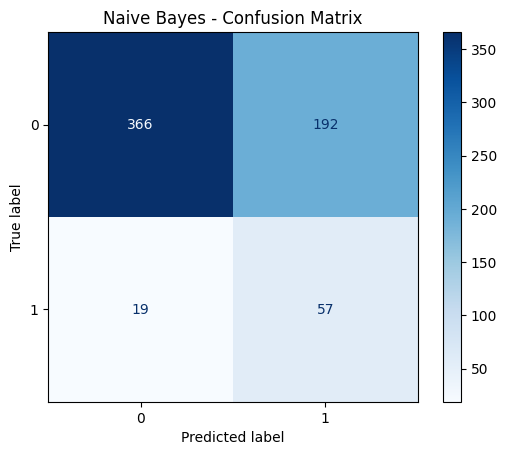


🔹 Training SVM...
ROC-AUC: 0.7854
F1-Score: 0.3734
              precision    recall  f1-score   support

         0.0       0.96      0.68      0.79       558
         1.0       0.25      0.78      0.37        76

    accuracy                           0.69       634
   macro avg       0.60      0.73      0.58       634
weighted avg       0.87      0.69      0.74       634



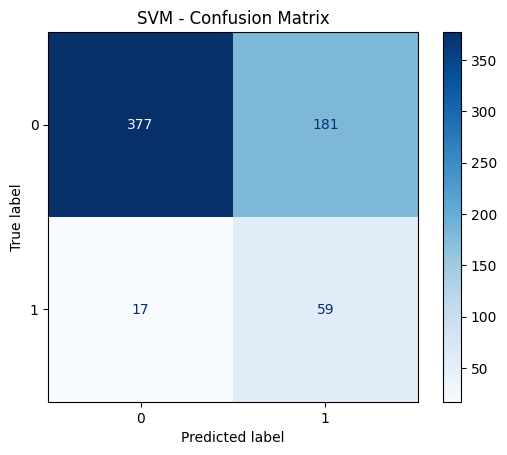


🔹 Training XGBoost...
ROC-AUC: 0.7788
F1-Score: 0.3173
              precision    recall  f1-score   support

         0.0       0.91      0.82      0.87       558
         1.0       0.25      0.43      0.32        76

    accuracy                           0.78       634
   macro avg       0.58      0.63      0.59       634
weighted avg       0.83      0.78      0.80       634



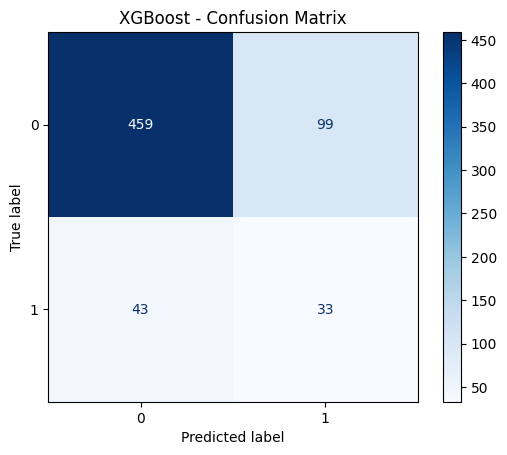


🏆 BEST MODEL: Logistic Regression with ROC-AUC: 0.7942


In [83]:
results = train_and_evaluate_model_SMOTE(models, X_train, y_train, X_test, y_test)

# Find best model
best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['model']
print(f"\n🏆 BEST MODEL: {best_model_name} with ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")